# 🎯 CareerAtlas Gap Analysis — Agent vs Naive LLM Evaluation

### What this notebook proves

**Why is my RAG agent better than just calling an LLM and asking?**

We run **two approaches** on realistic user profiles:

|           | **Approach A: My Agent**                       | **Approach B: Naive LLM** |
| --------- | ---------------------------------------------- | ------------------------- |
| Retrieval | Pinecone Semantic + BM25 + RRF + Jina Reranker | ❌ None                   |
| Context   | Real job-market taxonomy data                  | Only LLM's training data  |
| Pipeline  | 4-stage hybrid retrieval → structured LLM      | Direct prompt → LLM       |

An **independent LLM judge** (Google Gemini) then compares both outputs side-by-side and scores them 1–10.


---

## 0. Environment Setup


In [ ]:
import os

# ═══════════════════════════════════════════════════════════════════════════
# 🔑  PUT YOUR API KEYS HERE
# ═══════════════════════════════════════════════════════════════════════════
os.environ["GOOGLE_API_KEY"]   = ""   # Google AI Studio
os.environ["JINA_API_KEY"]     = ""   # jina.ai
os.environ["PINECONE_API_KEY"] = ""   # Pinecone dashboard
os.environ["PINECONE_HOST"]    = ""   # Pinecone index host URL
os.environ["GROQ_API_KEY"]     = ""   # Groq console
os.environ["GROQ_MODEL"]       = "llama-3.3-70b-versatile"
# ══════════════════════════════════════════════════════════════════════

print("✅ Environment variables set.")

✅ Environment variables set.


In [ ]:
# Install dependencies (uncomment and run once if needed)
!pip install pinecone langchain-google-genai langchain-groq rank-bm25 httpx pydantic matplotlib seaborn numpy google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 10.1 MB/s eta 0:00:00


---

## 1. Build the Agent Pipeline (Exact Replica)


In [ ]:
# ── 1a. Core Imports & AI Services ──────────────────────────────────
import httpx, json, time
from typing import List, Dict, Tuple, Any
from pydantic import BaseModel, Field
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from pinecone import Pinecone
from rank_bm25 import BM25Okapi

TASK_PREFIXES = {
    "retrieval_query":    "Represent this query for searching relevant passages: ",
    "retrieval_document": "Represent this document for retrieval: ",
    "semantic_similarity": "Represent this sentence for semantic similarity: ",
}

class AIService:
    def __init__(self):
        self.jina_api_key = os.environ["JINA_API_KEY"]
        self.google_api_key = os.environ["GOOGLE_API_KEY"]

    async def get_embeddings(self, texts: List[str], task_type: str = "retrieval_query"):
        prefix = TASK_PREFIXES.get(task_type, "")
        prefixed = [prefix + t for t in texts]
        emb = GoogleGenerativeAIEmbeddings(
            model="models/gemini-embedding-2-preview",
            google_api_key=self.google_api_key, task_type=task_type
        )
        return await emb.aembed_documents(prefixed)

    async def rerank(self, query: str, documents: List[str], top_n: int = 5):
        if not documents: return []
        async with httpx.AsyncClient(timeout=30.0) as client:
            resp = await client.post(
                "https://api.jina.ai/v1/rerank",
                headers={"Authorization": f"Bearer {self.jina_api_key}"},
                json={"model": "jina-reranker-v3", "query": query, "documents": documents, "top_n": top_n}
            )
            resp.raise_for_status()
            return resp.json()["results"]

ai_service = AIService()
print("✅ AIService ready.")

✅ AIService ready.


In [ ]:
# ── 1b. Pinecone + Role Mapping ──────────────────────────────────────────
def get_pinecone_index():
    pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])
    host = os.environ.get("PINECONE_HOST", "")
    # Connect by host if provided, otherwise connect by index name to 'careeratlas'
    return pc.Index(host=host) if host else pc.Index("careeratlas")

ROLE_SLUG_MAP = {
    "machine learning engineer": "ml_engineer",
    "data scientist": "data_scientist",
    "backend engineer": "swe_backend",
    "devops engineer": "devops_engineer",
    "data analyst": "data_analyst",
    "frontend engineer": "frontend_engineer",
    "ml engineer": "ml_engineer",
}

def resolve_role_slug(title: str) -> str:
    n = title.strip().lower()
    return ROLE_SLUG_MAP.get(n, n.replace(" ", "_"))

stats = get_pinecone_index().describe_index_stats()
print(f"✅ Pinecone connected. Vectors: {stats.get('total_vector_count')}, Dim: {stats.get('dimension')}")

✅ Pinecone connected. Vectors: 139, Dim: 3072


In [ ]:
# ── 1c. BM25 Corpus ───────────────────────────────────────────────
def _build_bm25_corpus(role_slug: str):
    idx = get_pinecone_index()
    results = idx.query(vector=[0.0]*3072, top_k=10000, namespace="taxonomy",
                        filter={"role": {"$eq": role_slug}}, include_metadata=True)
    corpus, metas = [], []
    for m in results["matches"]:
        md = m["metadata"]
        corpus.append(f"{md['skill_name']}. {md['description']}")
        metas.append(md)
    tok = [d.lower().split() for d in corpus]
    bm25 = BM25Okapi(tok) if tok else None
    return bm25, corpus, metas

bm25, _, metas = _build_bm25_corpus("ml_engineer")
print(f"✅ BM25 corpus: {len(metas)} skills for ml_engineer.")

✅ BM25 corpus: 30 skills for ml_engineer.


In [ ]:
# ── 1d. Full Hybrid Retrieval ──────────────────────────────────────
async def hybrid_retrieve(user_skills, target_role, headline="",
                          sem_k=20, bm25_k=20, fused_n=15, rerank_n=10):
    slug = resolve_role_slug(target_role)
    idx = get_pinecone_index()

    # 1. Semantic
    q = (f"Identify essential skills for a {target_role}. "
         f"The candidate is a {headline or 'professional'}. "
         f"Known skills: {', '.join(user_skills)}")
    vec = (await ai_service.get_embeddings([q], task_type="retrieval_query"))[0]
    sem = idx.query(vector=vec, top_k=sem_k, namespace="taxonomy",
                    filter={"role": {"$eq": slug}}, include_metadata=True)

    # 2. BM25
    bm25, _, meta_list = _build_bm25_corpus(slug)
    lookup = {m["skill_name"]: m for m in meta_list}
    bm25_map = {}
    if bm25:
        scores = bm25.get_scores(" ".join(user_skills).lower().split())
        for i, s in enumerate(scores): bm25_map[meta_list[i]["skill_name"]] = s

    # 3. RRF
    k = 60
    rrf, skill_meta = {}, {}
    for rank, m in enumerate(sem["matches"]):
        name = m["metadata"]["skill_name"]
        rrf[name] = rrf.get(name, 0) + 1.0/(k+rank+1)
        skill_meta[name] = m["metadata"]
    if bm25_map:
        for rank, (name, _) in enumerate(sorted(bm25_map.items(), key=lambda x: x[1], reverse=True)[:bm25_k]):
            rrf[name] = rrf.get(name, 0) + 1.0/(k+rank+1)
            if name not in skill_meta and name in lookup: skill_meta[name] = lookup[name]
    top = sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:fused_n]

    # 4. Rerank
    docs = [f"{n}: {skill_meta.get(n,{}).get('description','')}" for n,_ in top]
    names = [n for n,_ in top]
    pq = f"A professional with skills: {', '.join(user_skills)}. What are the most important missing skills for a {target_role}?"
    reranked = await ai_service.rerank(query=pq, documents=docs, top_n=rerank_n)
    out = []
    for r in reranked:
        n = names[r["index"]]
        meta = skill_meta.get(n, {})
        meta["relevance_score"] = r["relevance_score"]
        out.append(meta)
    return out

print("✅ Hybrid retrieval defined.")

✅ Hybrid retrieval defined.


In [ ]:
# ── 1e. Schemas + LLM Prompt ────────────────────────────────────────
class GapSchema(BaseModel):
    skill: str = Field(description="Name of the missing skill")
    category: str = Field(description="framework | language | concept | tool | soft")
    relevance: int = Field(description="Relevance score 0-100 (MUST BE AN INTEGER, NO QUOTES)")
    difficulty: str = Field(description="Easy, Medium, or Hard")
    level_required: str = Field(default="intermediate")
    prerequisites: List[str] = Field(description="Skills needed to learn this")
    why: str = Field(description="1 sentence explanation")

class GapAnalysisResponse(BaseModel):
    gaps: List[GapSchema] = Field(description="Top 6 skill gaps")

GAP_PROMPT = PromptTemplate.from_template(
"""You are an expert career coach and technical recruiter.

Identify the top 6 most critical SKILL GAPS for a candidate wanting to become a {target_role}.

## USER CURRENT SKILLS
{user_skills}

## RETRIEVED ROLE REQUIREMENTS (ranked by relevance)
{role_requirements}

## RULES
1. Compare the user's current skills against each requirement.
2. If the user already has a skill (or a very close equivalent), do NOT include it.
3. Rank the 6 gaps by importance: most critical first.
4. Use the category field from the requirements.
5. Use the level_required from the requirements when available.
6. For prerequisites, list only skills the user does NOT already have.
7. The \"why\" field must be a single concise sentence.
8. The \"relevance\" score MUST BE AN INTEGER (0-100), NOT A STRING.

Output strictly as JSON matching the schema.""")

print("✅ Schemas and prompt defined.")

✅ Schemas and prompt defined.


In [ ]:
# ── 1f. Agent Pipeline (generate_gaps) ─────────────────────────────
async def run_agent_pipeline(user_skills, target_role, headline=""):
    """Runs the FULL agent pipeline: Hybrid Retrieval → LLM."""
    retrieved = await hybrid_retrieve(user_skills, target_role, headline)

    # Format retrieved context for LLM
    lines = []
    for i, s in enumerate(retrieved, 1):
        prereqs = ", ".join(s.get("prerequisites", []))
        lines.append(
            f"{i}. {s['skill_name']} [{s.get('category','?')}] "
            f"(level: {s.get('level_required','intermediate')}) "
            f"— {s.get('description','N/A')} "
            f"(prerequisites: {prereqs or 'none'}) "
            f"[relevance_score: {s.get('relevance_score',0):.3f}]")
    context = "\n".join(lines)

    model = ChatGroq(model=os.environ.get("GROQ_MODEL", "llama-3.3-70b-versatile"),
                     groq_api_key=os.environ["GROQ_API_KEY"], temperature=0.0)
    chain = GAP_PROMPT | model.with_structured_output(GapAnalysisResponse)
    result = await chain.ainvoke({
        "target_role": target_role,
        "user_skills": ", ".join(user_skills),
        "role_requirements": context,
    })

    # Deduplicate
    deduped, seen = [], set()
    for g in result.gaps:
        k = g.skill.strip().lower()
        if k and k not in seen: seen.add(k); deduped.append(g)
    return [g.model_dump() for g in deduped], context

print("✅ Agent pipeline defined.")

✅ Agent pipeline defined.


---

## 2. Build the Naive LLM Baseline

This is what happens if you **just ask an LLM** the same question **without any retrieval**.


In [ ]:
NAIVE_PROMPT = PromptTemplate.from_template(
"""You are an expert career coach and technical recruiter.

Identify the top 6 most critical SKILL GAPS for a candidate wanting to become a {target_role}.

## USER CURRENT SKILLS
{user_skills}

## RULES
1. If the user already has a skill (or a very close equivalent), do NOT include it.
2. Rank the 6 gaps by importance: most critical first.
3. Use categories: framework | language | concept | tool | soft.
4. The \"why\" field must be a single concise sentence.
5. The \"relevance\" score MUST BE AN INTEGER (0-100), NOT A STRING.

Output strictly as JSON matching the schema.""")


async def run_naive_llm(user_skills, target_role):
    """Just asks the LLM directly. NO retrieval, NO context."""
    model = ChatGroq(model=os.environ.get("GROQ_MODEL", "llama-3.3-70b-versatile"),
                     groq_api_key=os.environ["GROQ_API_KEY"], temperature=0.0)
    chain = NAIVE_PROMPT | model.with_structured_output(GapAnalysisResponse)
    result = await chain.ainvoke({
        "target_role": target_role,
        "user_skills": ", ".join(user_skills),
    })
    deduped, seen = [], set()
    for g in result.gaps:
        k = g.skill.strip().lower()
        if k and k not in seen: seen.add(k); deduped.append(g)
    return [g.model_dump() for g in deduped]

print("✅ Naive LLM baseline defined.")

✅ Naive LLM baseline defined.


---

## 3. Define Realistic Test Personas (10 Total)

These are simulated profiles built to look like real-world resumes, containing messy, specific skills rather than just broad categories.


In [ ]:
TEST_PERSONAS = [
    {
        "name": "Backend → ML Engineer",
        "headline": "Backend Developer with 3 years experience",
        "target_role": "Machine Learning Engineer",
        "skills": ["Python", "Django", "FastAPI", "PostgreSQL", "Redis", "Docker", "Git", "RESTful APIs", "AWS EC2", "Jenkins", "Basic NumPy"],
    },
    {
        "name": "Data Analyst → Data Scientist",
        "headline": "Senior Business Data Analyst",
        "target_role": "Data Scientist",
        "skills": ["SQL", "Advanced Excel", "Tableau", "Google Analytics", "Python", "Pandas", "Matplotlib", "A/B Testing", "Basic Statistics", "Jupyter Notebooks"],
    },
    {
        "name": "Fresh CS Grad → Backend Engineer",
        "headline": "Computer Science Graduate (B.S.)",
        "target_role": "Backend Engineer",
        "skills": ["C++", "Java", "Object-Oriented Programming (OOP)", "Data Structures", "Algorithms", "HTML/CSS", "Basic SQL", "GitHub", "Academic Python"],
    },
    {
        "name": "DevOps → ML Engineer (Switch)",
        "headline": "DevOps & Cloud Infrastructure Engineer",
        "target_role": "Machine Learning Engineer",
        "skills": ["Kubernetes", "Docker", "Terraform", "AWS (S3, VPC, IAM)", "CI/CD Pipelines", "Bash scripting", "Python automation scripts", "Linux Administration", "Prometheus", "Grafana"],
    },
    {
        "name": "Frontend Dev → Full Stack Engineer",
        "headline": "React Frontend Developer",
        "target_role": "Backend Engineer",
        "skills": ["React", "Vue.js", "CSS", "Tailwind", "HTML5", "JavaScript", "TypeScript", "Webpack", "NPM", "Figma", "Jest"],
    },
    {
        "name": "IT Support → DevOps Engineer",
        "headline": "IT Support Specialist",
        "target_role": "DevOps Engineer",
        "skills": ["Windows Server", "Active Directory", "Hardware Troubleshooting", "Basic Bash", "Networking Fundamentals", "TCP/IP", "Helpdesk Ticketing", "Customer Service"],
    },
    {
        "name": "Marketing Manager → Data Analyst",
        "headline": "Digital Marketing Manager",
        "target_role": "Data Analyst",
        "skills": ["Google Analytics", "Microsoft Excel", "SEO", "Content Marketing", "Basic SQL", "HubSpot", "Social Media Management", "Campaign Strategy"],
    },
    {
        "name": "Software Engineer → ML Engineer",
        "headline": "Enterprise Software Engineer (Java)",
        "target_role": "Machine Learning Engineer",
        "skills": ["Java", "Spring Boot", "MySQL", "Microservices", "REST APIs", "Git", "Agile/Scrum", "Basic Python", "JUnit"],
    },
    {
        "name": "Data Analyst → ML Engineer",
        "headline": "Data Analyst with Python Experience",
        "target_role": "Machine Learning Engineer",
        "skills": ["SQL", "Python", "Pandas", "Seaborn", "Tableau", "Scikit-learn (Basic)", "Basic Statistics", "Linear Regression", "Jupyter"],
    },
    {
        "name": "Mobile Dev → Backend Engineer",
        "headline": "iOS Developer",
        "target_role": "Backend Engineer",
        "skills": ["Swift", "iOS SDK", "Xcode", "CoreData", "Firebase", "SQLite", "UI/UX Design", "App Store Deployment", "REST API Consumption"],
    }
]

print(f"✅ {len(TEST_PERSONAS)} realistic test personas ready.")

✅ 10 realistic test personas ready.


---

## 4. Run Both Approaches on Each Persona


In [ ]:
all_results = []

for p in TEST_PERSONAS:
    print(f"\n{'='*70}")
    print(f"🧪 {p['name']}")
    print(f"   Skills: {', '.join(p['skills'])}")
    print(f"   Target: {p['target_role']}")
    print(f"{'='*70}")

    # ── Run Agent ──
    print("\n   🤖 Running AGENT (Retrieval + LLM)...")
    t0 = time.time()
    agent_gaps, agent_context = await run_agent_pipeline(p["skills"], p["target_role"], p["headline"])
    agent_time = time.time() - t0
    print(f"   ✅ Agent done in {agent_time:.2f}s — {len(agent_gaps)} gaps")
    for i, g in enumerate(agent_gaps, 1):
        print(f"      {i}. {g['skill']} [{g['category']}] — {g['relevance']}%")

    # ── Run Naive LLM ──
    print("\n   💬 Running NAIVE LLM (No Retrieval)...")
    t0 = time.time()
    naive_gaps = await run_naive_llm(p["skills"], p["target_role"])
    naive_time = time.time() - t0
    print(f"   ✅ Naive done in {naive_time:.2f}s — {len(naive_gaps)} gaps")
    for i, g in enumerate(naive_gaps, 1):
        print(f"      {i}. {g['skill']} [{g['category']}] — {g['relevance']}%")

    all_results.append({
        "persona": p,
        "agent_gaps": agent_gaps, "agent_time": round(agent_time, 2),
        "agent_context": agent_context,
        "naive_gaps": naive_gaps, "naive_time": round(naive_time, 2),
    })

print(f"\n✅ All {len(all_results)} personas processed.")


🧪 Backend → ML Engineer
   Skills: Python, Django, FastAPI, PostgreSQL, Redis, Docker, Git, RESTful APIs, AWS EC2, Jenkins, Basic NumPy
   Target: Machine Learning Engineer

   🤖 Running AGENT (Retrieval + LLM)...
   ✅ Agent done in 4.34s — 6 gaps
      1. MLOps fundamentals [concept] — 100%
      2. Model evaluation and metrics [concept] — 96%
      3. Statistics and probability [concept] — 94%
      4. scikit-learn [framework] — 92%
      5. Experiment tracking (MLflow) [tool] — 90%
      6. Linear Algebra [concept] — 88%

   💬 Running NAIVE LLM (No Retrieval)...
   ✅ Naive done in 1.38s — 6 gaps
      1. TensorFlow [framework] — 98%
      2. R [language] — 95%
      3. Deep Learning [concept] — 92%
      4. Jupyter Notebook [tool] — 90%
      5. PyTorch [framework] — 88%
      6. Unsupervised Learning [concept] — 85%

🧪 Data Analyst → Data Scientist
   Skills: SQL, Advanced Excel, Tableau, Google Analytics, Python, Pandas, Matplotlib, A/B Testing, Basic Statistics, Jupyter Notebook

---

## 5. LLM-as-Judge: Head-to-Head Comparison using Google Gemini

An independent judge (Google Gemini 2.5 Flash) compares both outputs side-by-side to determine which is better for real users.


In [ ]:
JUDGE_PROMPT = """You are an impartial expert evaluator of AI career-coaching systems.

You are given a user profile and TWO different gap-analysis outputs:
- **System A**: Uses a hybrid retrieval pipeline (Pinecone semantic search + BM25 keyword matching + Reciprocal Rank Fusion + Jina cross-encoder reranking) to fetch real job-market taxonomy data BEFORE calling the LLM.
- **System B**: Directly asks the same LLM to generate gaps using ONLY its training knowledge. No retrieval.

Score EACH system on 5 dimensions (1-10 each):

1. **Relevance**: Are the gaps actually important for the target role in today's job market?
2. **Accuracy**: Does the system correctly EXCLUDE skills the user already has?
3. **Specificity**: Are the gaps concrete and specific (e.g., "PyTorch" not "deep learning frameworks")? Are difficulty/prerequisites precise?
4. **Grounding**: Are the recommendations grounded in real job requirements, or are they generic/hallucinated?
5. **Actionability**: Can the user immediately build a learning plan from this output?

---

**User Profile:**
- Headline: {headline}
- Current Skills: {user_skills}
- Target Role: {target_role}

**System A Output (Agent with Retrieval):**
{agent_output}

**System B Output (Naive LLM, No Retrieval):**
{naive_output}

---

Respond with ONLY valid JSON strictly adhering to this exact format:
{{
  "system_a": {{
    "relevance": {{"score": <int>, "reason": "<1 sentence>"}},
    "accuracy": {{"score": <int>, "reason": "<1 sentence>"}},
    "specificity": {{"score": <int>, "reason": "<1 sentence>"}},
    "grounding": {{"score": <int>, "reason": "<1 sentence>"}},
    "actionability": {{"score": <int>, "reason": "<1 sentence>"}}
  }},
  "system_b": {{
    "relevance": {{"score": <int>, "reason": "<1 sentence>"}},
    "accuracy": {{"score": <int>, "reason": "<1 sentence>"}},
    "specificity": {{"score": <int>, "reason": "<1 sentence>"}},
    "grounding": {{"score": <int>, "reason": "<1 sentence>"}},
    "actionability": {{"score": <int>, "reason": "<1 sentence>"}}
  }},
  "winner": "A" or "B" or "Tie",
  "why_winner_is_better": "<2-3 sentence explanation>"
}}
"""

print("✅ Judge prompt defined.")

✅ Judge prompt defined.


In [ ]:
import google.generativeai as genai
import json
import time
import asyncio
from google.api_core import exceptions

# Split the comma-separated keys from environment variable
raw_keys = os.environ.get("GOOGLE_API_KEY", "")
GOOGLE_API_KEYS = [k.strip() for k in raw_keys.split(",") if k.strip()]
key_index = 0

def get_configured_model():
    global key_index
    if not GOOGLE_API_KEYS:
        raise ValueError("No API keys found in GOOGLE_API_KEY environment variable.")

    current_key = GOOGLE_API_KEYS[key_index]
    print(f"   🔑 Using key index {key_index} (starts with {current_key[:8]}...)")

    # Re-configure and return a fresh model instance bound to this config
    genai.configure(api_key=current_key)
    model = genai.GenerativeModel(
        "gemini-2.5-flash",
        generation_config={"response_mime_type": "application/json"}
    )

    key_index = (key_index + 1) % len(GOOGLE_API_KEYS)
    return model

judgments = []

for r in all_results:
    p = r["persona"]
    print(f"\n🔍 Judging: {p['name']}...")

    prompt = JUDGE_PROMPT.format(
        headline=p["headline"],
        user_skills=", ".join(p["skills"]),
        target_role=p["target_role"],
        agent_output=json.dumps(r["agent_gaps"], indent=2),
        naive_output=json.dumps(r["naive_gaps"], indent=2),
    )

    success = False
    retries = 0
    max_retries = len(GOOGLE_API_KEYS) * 2

    while not success and retries < max_retries:
        try:
            # Get a fresh model with the next key in the rotation
            judge_model = get_configured_model()
            resp = judge_model.generate_content(prompt)
            raw = resp.text.strip()
            success = True
        except (exceptions.TooManyRequests, exceptions.InvalidArgument, exceptions.InternalServerError) as e:
            retries += 1
            wait_time = 2 if "key" in str(e).lower() else 5
            print(f"   ⚠️ API Issue: {type(e).__name__}. Rotating key and retrying in {wait_time}s...")
            time.sleep(wait_time)
        except Exception as e:
            print(f"   ❌ Fatal Error: {e}")
            raw = "{}"
            break

    if not success:
        judgments.append({"persona": p["name"], "judgment": {"error": "Failed after rotation retries"}})
        continue

    # Clean up output
    if raw.startswith("```"): raw = raw.split("\n", 1)[1]
    if "```" in raw: raw = raw.split("```")[0]
    if raw.startswith("json"): raw = raw[4:].strip()
    raw = raw.strip()

    try:
        j = json.loads(raw)
    except json.JSONDecodeError:
        print(f"   ⚠️ Parse error. Raw: {raw[:100]}")
        j = {"error": "Parse error"}

    # Calculate totals
    dims = ["relevance", "accuracy", "specificity", "grounding", "actionability"]
    for sys_key in ["system_a", "system_b"]:
        if sys_key in j:
            try:
                scores = [j[sys_key][dim]["score"] for dim in dims if dim in j[sys_key]]
                j[sys_key]["total"] = sum(scores) / len(scores) if scores else 0
            except:
                j[sys_key]["total"] = 0

    judgments.append({"persona": p["name"], "role": p["target_role"], "judgment": j,
                      "agent_time": r["agent_time"], "naive_time": r["naive_time"]})

    if "system_a" in j:
        a, b = j["system_a"].get("total", 0), j["system_b"].get("total", 0)
        w = j.get("winner", "?")
        print(f"   🤖 Agent: {a:.1f}/10  vs  💬 Naive: {b:.1f}/10  →  Winner: {w}")

print(f"\n✅ All {len(judgments)} judgments processed with key rotation.")


🔍 Judging: Backend → ML Engineer...
   🔑 Using key index 0 (starts with AIzaSyA-...)


   ⚠️ API Issue: TooManyRequests. Rotating key and retrying in 5s...
   🔑 Using key index 1 (starts with AIzaSyA7...)
   🤖 Agent: 9.0/10  vs  💬 Naive: 7.2/10  →  Winner: A

🔍 Judging: Data Analyst → Data Scientist...
   🔑 Using key index 2 (starts with AIzaSyAd...)


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 4252.43ms


   🤖 Agent: 8.8/10  vs  💬 Naive: 7.2/10  →  Winner: A

🔍 Judging: Fresh CS Grad → Backend Engineer...
   🔑 Using key index 0 (starts with AIzaSyA-...)


   ⚠️ API Issue: TooManyRequests. Rotating key and retrying in 5s...
   🔑 Using key index 1 (starts with AIzaSyA7...)
   🤖 Agent: 9.0/10  vs  💬 Naive: 6.2/10  →  Winner: A

🔍 Judging: DevOps → ML Engineer (Switch)...
   🔑 Using key index 2 (starts with AIzaSyAd...)
   🤖 Agent: 9.4/10  vs  💬 Naive: 7.6/10  →  Winner: A

🔍 Judging: Frontend Dev → Full Stack Engineer...
   🔑 Using key index 0 (starts with AIzaSyA-...)


...

   🤖 Agent: 9.4/10  vs  💬 Naive: 5.4/10  →  Winner: A

🔍 Judging: IT Support → DevOps Engineer...
   🔑 Using key index 2 (starts with AIzaSyAd...)
   🤖 Agent: 9.0/10  vs  💬 Naive: 7.2/10  →  Winner: A

🔍 Judging: Marketing Manager → Data Analyst...
   🔑 Using key index 0 (starts with AIzaSyA-...)


   ⚠️ API Issue: TooManyRequests. Rotating key and retrying in 5s...
   🔑 Using key index 1 (starts with AIzaSyA7...)
   🤖 Agent: 9.2/10  vs  💬 Naive: 5.8/10  →  Winner: A

🔍 Judging: Software Engineer → ML Engineer...
   🔑 Using key index 2 (starts with AIzaSyAd...)
   🤖 Agent: 9.6/10  vs  💬 Naive: 8.4/10  →  Winner: A

🔍 Judging: Data Analyst → ML Engineer...
   🔑 Using key index 0 (starts with AIzaSyA-...)


   ⚠️ API Issue: TooManyRequests. Rotating key and retrying in 5s...
   🔑 Using key index 1 (starts with AIzaSyA7...)
   🤖 Agent: 9.2/10  vs  💬 Naive: 5.0/10  →  Winner: A

🔍 Judging: Mobile Dev → Backend Engineer...
   🔑 Using key index 2 (starts with AIzaSyAd...)


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2759.49ms


   🤖 Agent: 9.0/10  vs  💬 Naive: 4.2/10  →  Winner: A

✅ All 10 judgments processed with key rotation.


---

## 6. Graphical Evaluation Scorecard

Visualising the difference in quality between the Agent pipeline and the Naive LLM.


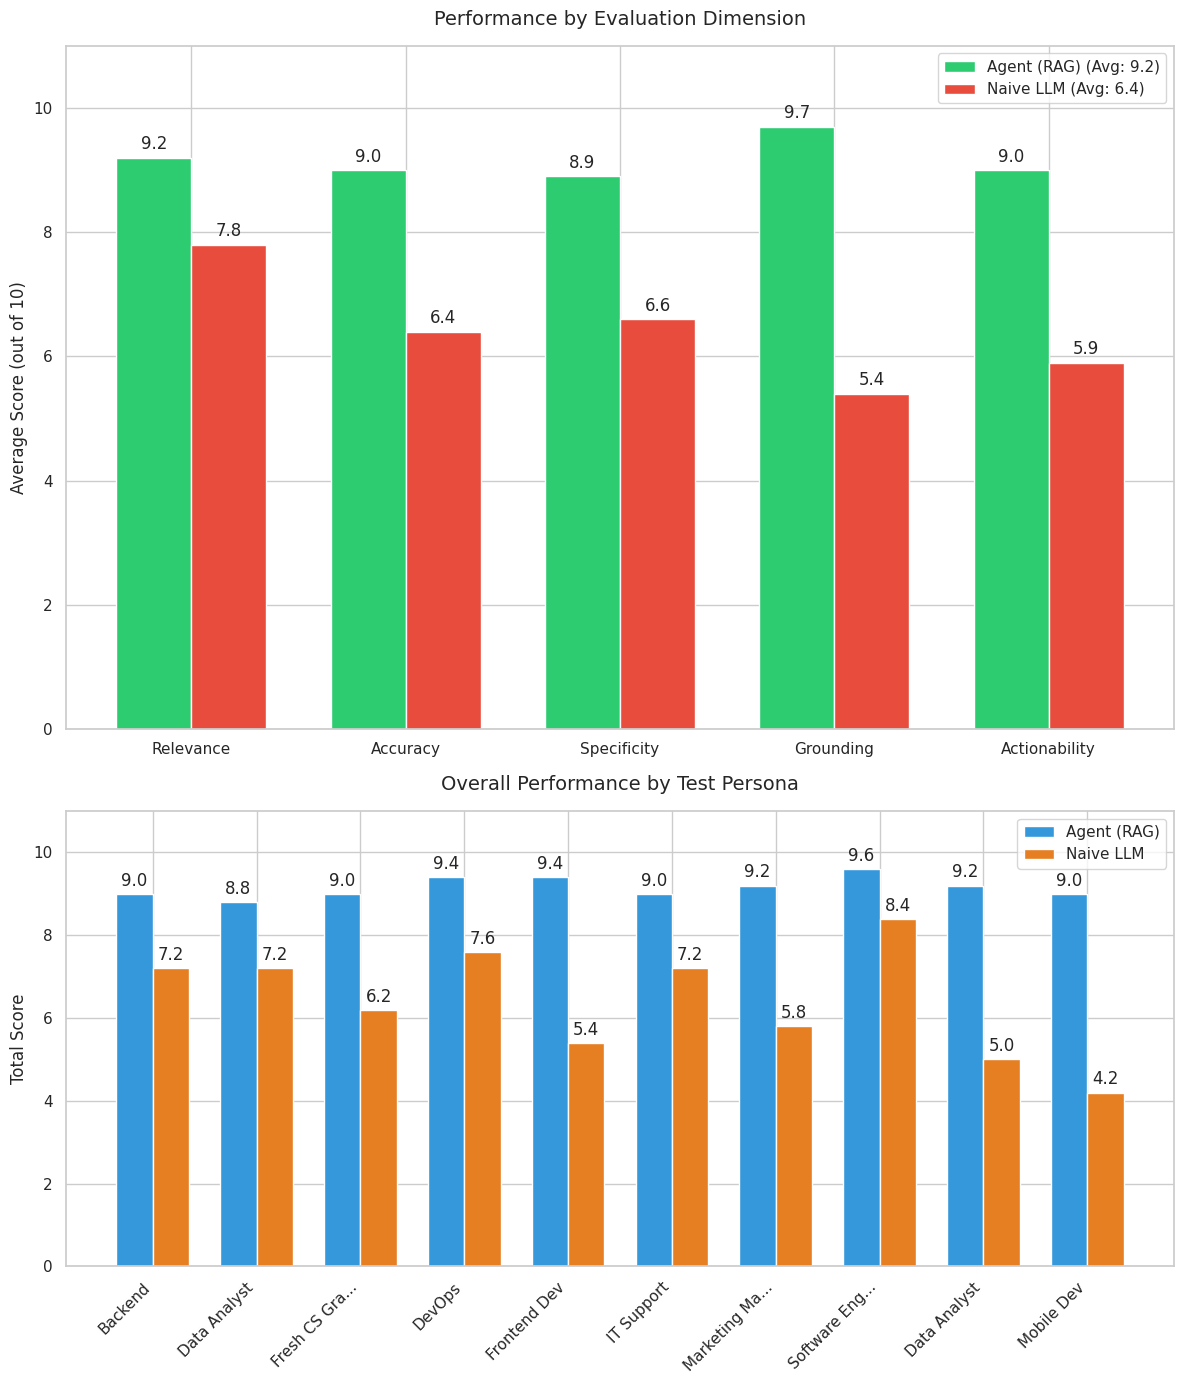

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn style for beautiful plots
sns.set_theme(style="whitegrid", palette="muted")

dims = ["Relevance", "Accuracy", "Specificity", "Grounding", "Actionability"]
agent_scores_by_dim = {d: [] for d in dims}
naive_scores_by_dim = {d: [] for d in dims}
persona_names = []
agent_totals = []
naive_totals = []

for jdg in judgments:
    j = jdg["judgment"]
    if "error" in j: continue

    persona_names.append(jdg["persona"])
    agent_totals.append(j["system_a"]["total"])
    naive_totals.append(j["system_b"]["total"])

    for dim in dims:
        d_key = dim.lower()
        agent_scores_by_dim[dim].append(j["system_a"][d_key]["score"])
        naive_scores_by_dim[dim].append(j["system_b"][d_key]["score"])

# Calculate averages
agent_avg_dims = [np.mean(agent_scores_by_dim[d]) for d in dims]
naive_avg_dims = [np.mean(naive_scores_by_dim[d]) for d in dims]

overall_agent_avg = np.mean(agent_totals)
overall_naive_avg = np.mean(naive_totals)

# ──────────────────────────────────────────────────
# PLOT 1: Grouped Bar Chart by Evaluation Dimension
# ──────────────────────────────────────────────────
x = np.arange(len(dims))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14), gridspec_kw={'height_ratios': [1.5, 1]})

# --- First Subplot: Dimension Averages ---
rects1 = ax1.bar(x - width/2, agent_avg_dims, width, label=f'Agent (RAG) (Avg: {overall_agent_avg:.1f})', color='#2ecc71')
rects2 = ax1.bar(x + width/2, naive_avg_dims, width, label=f'Naive LLM (Avg: {overall_naive_avg:.1f})', color='#e74c3c')

ax1.set_ylabel('Average Score (out of 10)')
ax1.set_title('Performance by Evaluation Dimension', fontsize=14, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(dims)
ax1.set_ylim(0, 11)
ax1.legend()

ax1.bar_label(rects1, padding=3, fmt='%.1f')
ax1.bar_label(rects2, padding=3, fmt='%.1f')

# ──────────────────────────────────────────────────
# PLOT 2: Overall Score by Persona
# ──────────────────────────────────────────────────
x_personas = np.arange(len(persona_names))

rects3 = ax2.bar(x_personas - width/2, agent_totals, width, label='Agent (RAG)', color='#3498db')
rects4 = ax2.bar(x_personas + width/2, naive_totals, width, label='Naive LLM', color='#e67e22')

ax2.set_ylabel('Total Score')
ax2.set_title('Overall Performance by Test Persona', fontsize=14, pad=15)
ax2.set_xticks(x_personas)
# Simplify labels for display
short_labels = [name.split(" → ")[0][:12] + "..." if len(name.split(" → ")[0]) > 12 else name.split(" → ")[0] for name in persona_names]
ax2.set_xticklabels(short_labels, rotation=45, ha='right')
ax2.set_ylim(0, 11)
ax2.legend()

ax2.bar_label(rects3, padding=3, fmt='%.1f')
ax2.bar_label(rects4, padding=3, fmt='%.1f')

plt.tight_layout()
plt.show()

In [ ]:
# ── Judge's Qualitative Reasoning ──
print("\n" + "="*70)
print("📝 WHY THE AGENT WINS (Judge's Reasoning)")
print("="*70)

for jdg in judgments:
    j = jdg["judgment"]
    if "error" in j: continue
    print(f"\n{'─'*70}")
    print(f"🧪 {jdg['persona']} → {jdg['role']}")
    print(f"   Winner: {'🤖 Agent' if j['winner']=='A' else '💬 Naive' if j['winner']=='B' else '🤝 Tie'}")
    print(f"   🗣️  {j['why_winner_is_better']}")
    print(f"\n   Key dimension differences:")
    for dim in ["relevance", "accuracy", "specificity", "grounding", "actionability"]:
        a = j["system_a"][dim]
        b = j["system_b"][dim]
        diff = a["score"] - b["score"]
        if diff != 0:
            arrow = "▲" if diff > 0 else "▼"
            print(f"     {dim:15s}: Agent {a['score']} vs Naive {b['score']} ({arrow}{abs(diff)}) — {a['reason']}")


📝 WHY THE AGENT WINS (Judge's Reasoning)

──────────────────────────────────────────────────────────────────────
🧪 Backend → ML Engineer → Machine Learning Engineer
   Winner: 🤖 Agent
   🗣️  System A provides a more targeted and strategically sound set of skill gaps, focusing on foundational knowledge like MLOps and mathematical principles that are critical for an MLE transition. Its recommendations are better grounded in real job market needs due to its retrieval mechanism, ensuring a more efficient and relevant learning path. System B, by contrast, includes less optimal choices like R and broad concepts, making its guidance less precise and effective for the user's specific career goal.

   Key dimension differences:
     relevance      : Agent 9 vs Naive 7 (▲2) — The identified gaps, including MLOps and foundational math, are highly relevant and crucial for a backend developer transitioning to an MLE role in today's market.
     accuracy       : Agent 9 vs Naive 7 (▲2) — The system